In [1]:
import subprocess, sys
for pkg in ["transformers", "datasets", "torch", "scikit-learn",
            "pandas", "numpy", "tqdm", "matplotlib", "sentencepiece", "seaborn"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("All packages ready.")

All packages ready.


In [2]:
import os, json, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup, pipeline
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), "Enable GPU in Kaggle: Settings -> Accelerator -> GPU T4"
DEVICE = torch.device("cuda")
print(f"Device: {DEVICE} ({torch.cuda.get_device_name(0)})")

INPUT_DIR = "/kaggle/input/datasets"
WORK_DIR  = "/kaggle/working"

LABELS = ["clean", "profanity", "hate_speech", "threat", "identity_attack"]
print(f"Labels: {LABELS}")

Device: cuda (Tesla T4)
Labels: ['clean', 'profanity', 'hate_speech', 'threat', 'identity_attack']


##  Dataset Loading

We load two English datasets and five Nepali datasets across two different formats:

**Word-level BIO NER files** (`train.txt`, `valid.txt`, `test.txt`) — one word per line with tags like `B-PROFANITY`, `I-PROFANITY`, `B-VIOLENCE`, `B-GENERAL`. Sentences are separated by blank lines. The `bio_to_sentences()` function converts these to sentence-level labels: if any word in a sentence is tagged PROFANITY, the whole sentence gets `profanity=1`; VIOLENCE maps to `threat=1`; GENERAL maps to `hate_speech=1`.

**Sentence-level files** (`dataset.txt`, `ss_ac_at_txt_bal.csv`, `ss_ac_at_txt_unbal.csv`) — direct sentence classification, handled the same as before.

All six Nepali files should be uploaded to Kaggle as a dataset named `guardmeet-nepali`.

In [3]:
jigsaw_df = None
JIGSAW_PATH = os.path.join(INPUT_DIR,"julian3833","jigsaw-toxic-comment-classification-challenge", "train.csv")
try:
    jigsaw_df = pd.read_csv(JIGSAW_PATH)
    print(f"Jigsaw loaded: {len(jigsaw_df):,} rows")
    print(jigsaw_df[["toxic","severe_toxic","obscene","threat","insult","identity_hate"]].sum())
except FileNotFoundError:
    print("Jigsaw not found. Add via Data -> + Add Data -> jigsaw-toxic-comment-classification-challenge")

Jigsaw loaded: 159,571 rows
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


In [4]:
# HateEval is gated on HuggingFace and requires authentication.
# Skipping — Jigsaw at 160k rows is sufficient for English training data.
hateval_df = None
print("HateEval skipped (gated dataset). Using Jigsaw as primary English source.")

HateEval skipped (gated dataset). Using Jigsaw as primary English source.


In [5]:
NEPALI_DIR = os.path.join(INPUT_DIR,"hridayanshu23","nepali-dataset")
ne_ner_train = ne_ner_valid = ne_ner_test = None
ne_extra_df = ne_bal_df = ne_unbal_df = None

# ── BIO NER files (word-level -> convert to sentence-level) ──────────────
def bio_to_sentences(filepath):
    """
    Reads a BIO-tagged file (one word per line, blank lines = sentence boundaries).
    Returns a DataFrame with columns: text, profanity, threat, hate_speech, clean, language.
    Tag mapping:
      B/I-PROFANITY -> profanity=1
      B/I-VIOLENCE  -> threat=1
      B/I-GENERAL   -> hate_speech=1
      B/I-FEEDBACK  -> (ignored, treated as clean context)
      O             -> no label
    """
    rows = []
    words, tags = [], set()

    with open(filepath, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line == '':
                if words:
                    text      = ' '.join(words)
                    profanity = int(any('PROFANITY' in t for t in tags))
                    threat    = int(any('VIOLENCE'  in t for t in tags))
                    hate      = int(any('GENERAL'   in t for t in tags))
                    is_harm   = profanity or threat or hate
                    rows.append({
                        'text':            text,
                        'profanity':       profanity,
                        'threat':          threat,
                        'hate_speech':     int(is_harm),
                        'identity_attack': 0,
                        'clean':           int(not is_harm),
                        'language':        'ne'
                    })
                    words, tags = [], set()
            else:
                parts = line.split()
                if len(parts) == 2:
                    words.append(parts[0])
                    if parts[1] != 'O':
                        tags.add(parts[1])
    # flush last sentence
    if words:
        text      = ' '.join(words)
        profanity = int(any('PROFANITY' in t for t in tags))
        threat    = int(any('VIOLENCE'  in t for t in tags))
        hate      = int(any('GENERAL'   in t for t in tags))
        is_harm   = profanity or threat or hate
        rows.append({
            'text':            text,
            'profanity':       profanity,
            'threat':          threat,
            'hate_speech':     int(is_harm),
            'identity_attack': 0,
            'clean':           int(not is_harm),
            'language':        'ne'
        })
    return pd.DataFrame(rows)[LABELS + ['text', 'language']]


try:
    ne_ner_train = bio_to_sentences(os.path.join(NEPALI_DIR, 'train.txt'))
    ne_ner_valid = bio_to_sentences(os.path.join(NEPALI_DIR, 'valid.txt'))
    ne_ner_test  = bio_to_sentences(os.path.join(NEPALI_DIR, 'test.txt'))
    print(f'NER train.txt -> {len(ne_ner_train):,} sentences')
    print(f'NER valid.txt -> {len(ne_ner_valid):,} sentences')
    print(f'NER test.txt  -> {len(ne_ner_test):,} sentences')
    for name, df in [('train', ne_ner_train), ('valid', ne_ner_valid), ('test', ne_ner_test)]:
        hs = df['hate_speech'].sum()
        pr = df['profanity'].sum()
        th = df['threat'].sum()
        cl = df['clean'].sum()
        print(f'  {name}: clean={cl} hate={hs} profanity={pr} threat={th}')
except FileNotFoundError as e:
    print(f'NER files not found: {e}')

# ── Sentence-level dataset.txt (label 0-3) ────────────────────────────────
try:
    ne_extra_df = pd.read_csv(os.path.join(NEPALI_DIR, 'dataset.txt'),
                              sep='\t', header=None, names=['text', 'label'], encoding='utf-8')
    print(f'dataset.txt: {len(ne_extra_df):,} rows | labels: {ne_extra_df["label"].value_counts().to_dict()}')
except FileNotFoundError:
    print('dataset.txt not found, skipping.')

# ── SS-AC-AT CSV datasets ─────────────────────────────────────────────────
try:
    ne_bal_df   = pd.read_csv(os.path.join(NEPALI_DIR, 'ss_ac_at_txt_bal.csv'),
                              header=None, names=['label','cat','title','text'], encoding='utf-8')
    ne_unbal_df = pd.read_csv(os.path.join(NEPALI_DIR, 'ss_ac_at_txt_unbal.csv'),
                              header=None, names=['label','cat','title','text'], encoding='utf-8')
    print(f'ss_ac_at_txt_bal:   {len(ne_bal_df):,} rows')
    print(f'ss_ac_at_txt_unbal: {len(ne_unbal_df):,} rows')
except FileNotFoundError as e:
    print(f'CSV datasets not found: {e}')

NER train.txt -> 2,323 sentences
NER valid.txt -> 330 sentences
NER test.txt  -> 280 sentences
  train: clean=247 hate=2076 profanity=278 threat=214
  valid: clean=37 hate=293 profanity=37 threat=40
  test: clean=25 hate=255 profanity=36 threat=25
dataset.txt: 36 rows | labels: {1: 14, 0: 13, 2: 6, 3: 3}
ss_ac_at_txt_bal:   1,700 rows
ss_ac_at_txt_unbal: 4,035 rows


## Label Mapping and Unification

All datasets are mapped into the same 5-label schema used by GuardMeet. The Nepali 4-class labels map as follows: 0 -> clean, 1 -> hate_speech, 2 -> profanity + hate_speech, 3 -> threat + hate_speech.

In [6]:
def unify_labels(df, source_name):
    out = pd.DataFrame()

    if source_name == "jigsaw":
        out["text"]            = df["comment_text"].astype(str)
        out["profanity"]       = ((df["obscene"] == 1) | (df["severe_toxic"] == 1)).astype(int)
        out["hate_speech"]     = ((df["toxic"] == 1) | (df["insult"] == 1)).astype(int)
        out["threat"]          = (df["threat"] == 1).astype(int)
        out["identity_attack"] = (df["identity_hate"] == 1).astype(int)
        out["clean"]           = ((out[["profanity","hate_speech","threat","identity_attack"]].sum(axis=1)) == 0).astype(int)
        out["language"]        = "en"

    elif source_name == "hateval":
        out["text"]            = df["text"].astype(str)
        out["hate_speech"]     = df["hs"].astype(int)
        out["threat"]          = df["tr"].astype(int)
        out["profanity"]       = 0
        out["identity_attack"] = 0
        out["clean"]           = ((out[["hate_speech","threat"]].sum(axis=1)) == 0).astype(int)
        out["language"]        = "en"

    elif source_name in ("nepali_txt", "nepali_extra"):
        out["text"]            = df["text"].astype(str)
        out["clean"]           = (df["label"] == 0).astype(int)
        out["hate_speech"]     = (df["label"].isin([1, 2, 3])).astype(int)
        out["profanity"]       = (df["label"] == 2).astype(int)
        out["threat"]          = (df["label"] == 3).astype(int)
        out["identity_attack"] = 0
        out["language"]        = "ne"

    elif source_name == "nepali_csv":
        out["text"]            = df["text"].astype(str)
        is_harmful             = (df["label"] == 1)
        cat                    = df["cat"].fillna("GENERAL")
        out["clean"]           = (~is_harmful).astype(int)
        out["profanity"]       = (is_harmful & (cat == "PROFANITY")).astype(int)
        out["threat"]          = (is_harmful & (cat == "VIOLENCE")).astype(int)
        out["hate_speech"]     = is_harmful.astype(int)
        out["identity_attack"] = 0
        out["language"]        = "ne"

    else:
        raise ValueError(f"Unknown source: {source_name}")

    out = out[out["text"].str.strip().str.len() > 3].copy()
    out = out.drop_duplicates(subset=["text"]).reset_index(drop=True)
    return out[LABELS + ["text", "language"]]


print("unify_labels() defined.")

unify_labels() defined.


In [7]:
all_dfs = []

if jigsaw_df is not None:
    j_u = unify_labels(jigsaw_df, 'jigsaw')
    all_dfs.append(j_u)
    print(f'Jigsaw:            {len(j_u):,} rows')

if hateval_df is not None:
    h_u = unify_labels(hateval_df, 'hateval')
    all_dfs.append(h_u)
    print(f'HateEval:          {len(h_u):,} rows')

# NER-converted Nepali (already in LABELS format, no unify_labels needed)
if ne_ner_train is not None:
    ner_all = pd.concat([ne_ner_train, ne_ner_valid, ne_ner_test], ignore_index=True)
    ner_all = ner_all.drop_duplicates(subset=['text']).reset_index(drop=True)
    all_dfs.append(ner_all)
    print(f'Nepali NER (train+valid+test): {len(ner_all):,} sentences')

if ne_extra_df is not None:
    ne_extra_u = unify_labels(ne_extra_df, 'nepali_extra')
    all_dfs.append(ne_extra_u)
    print(f'Nepali dataset.txt:{len(ne_extra_u):,} rows')

if ne_bal_df is not None:
    ne_csv_u = unify_labels(pd.concat([ne_bal_df, ne_unbal_df], ignore_index=True), 'nepali_csv')
    all_dfs.append(ne_csv_u)
    print(f'Nepali CSV:        {len(ne_csv_u):,} rows')

print(f'\nTotal source DataFrames: {len(all_dfs)}')

Jigsaw:            159,571 rows
Nepali NER (train+valid+test): 2,920 sentences
Nepali dataset.txt:36 rows
Nepali CSV:        2,896 rows

Total source DataFrames: 4


Combined dataset: 162,722 rows
  English: 159,571
  Nepali:  3,151

Label distribution:
  clean               : 143,800 (88.4%)
  profanity           :  8,881 (5.5%)
  hate_speech         : 18,524 (11.4%)
  threat              :    760 (0.5%)
  identity_attack     :  1,405 (0.9%)


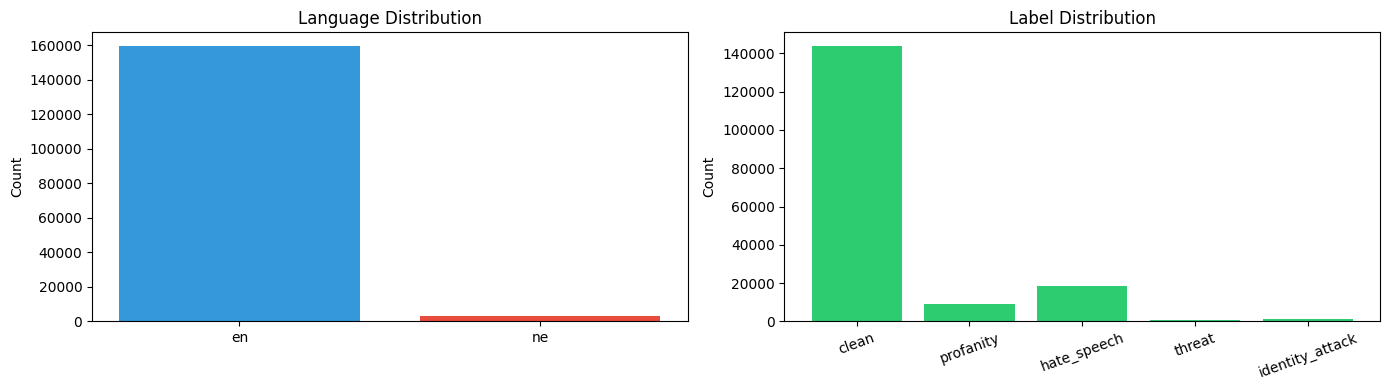

In [8]:
full_raw_df = pd.concat(all_dfs, ignore_index=True).drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"Combined dataset: {len(full_raw_df):,} rows")
print(f"  English: {(full_raw_df['language']=='en').sum():,}")
print(f"  Nepali:  {(full_raw_df['language']=='ne').sum():,}")
print()
print("Label distribution:")
for lbl in LABELS:
    n = full_raw_df[lbl].sum()
    print(f"  {lbl:20s}: {n:6,} ({100*n/len(full_raw_df):.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
lang_counts = full_raw_df["language"].value_counts()
axes[0].bar(lang_counts.index, lang_counts.values, color=["#3498db","#e74c3c"])
axes[0].set_title("Language Distribution")
axes[0].set_ylabel("Count")
label_sums = full_raw_df[LABELS].sum()
axes[1].bar(LABELS, label_sums.values, color="#2ecc71")
axes[1].set_title("Label Distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "dataset_distribution.png"), dpi=100, bbox_inches="tight")
plt.show()

##  Synthetic Nepali Data via Machine Translation

In [11]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm import tqdm
import torch
import pandas as pd

# =========================================================
# Settings
# =========================================================

SYNTH_SAMPLE_SIZE = 3000
BACK_TRANS_THRESHOLD = 0.3
BATCH_SIZE = 8
MODEL_NAME = "facebook/nllb-200-distilled-600M"

device = "cuda" if torch.cuda.is_available() else "cpu"

synth_ne_df = None

try:
    print("Loading NLLB-200 model...")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

    print("Model loaded successfully.")

    # =====================================================
    # Translation Function
    # =====================================================

    def translate_batch(texts, src_lang, tgt_lang):
        """
        Translate a batch of texts using NLLB.
        """

        tokenizer.src_lang = src_lang

        encoded = tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=200
        ).to(device)

        generated_tokens = model.generate(
            **encoded,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(tgt_lang),
            max_length=200
        )

        outputs = tokenizer.batch_decode(
            generated_tokens,
            skip_special_tokens=True
        )

        return outputs

    # =====================================================
    # Sample English Data
    # =====================================================

    en_pool = full_raw_df[
        full_raw_df["language"] == "en"
    ].copy()

    hate_pool = en_pool[
        en_pool["hate_speech"] == 1
    ].sample(
        min(
            SYNTH_SAMPLE_SIZE // 2,
            len(en_pool[en_pool["hate_speech"] == 1])
        ),
        random_state=SEED
    )

    clean_pool = en_pool[
        en_pool["hate_speech"] == 0
    ].sample(
        min(
            SYNTH_SAMPLE_SIZE // 2,
            len(en_pool[en_pool["hate_speech"] == 0])
        ),
        random_state=SEED
    )

    sample_en = pd.concat(
        [hate_pool, clean_pool],
        ignore_index=True
    )

    print(f"Selected {len(sample_en):,} English samples")

    # =====================================================
    # Quality Check
    # =====================================================

    def word_overlap(a, b):

        a_words = set(str(a).lower().split())
        b_words = set(str(b).lower().split())

        if len(a_words) == 0:
            return 0.0

        return len(a_words & b_words) / len(a_words)

    # =====================================================
    # Translation Loop
    # =====================================================

    translated_rows = []

    texts = (
        sample_en["text"]
        .astype(str)
        .str[:200]
        .tolist()
    )

    print("Starting EN -> NE translation...")

    for i in tqdm(
        range(0, len(texts), BATCH_SIZE),
        desc="Translating"
    ):

        batch_texts = texts[i:i + BATCH_SIZE]

        try:

            # ---------------------------------------------
            # English -> Nepali
            # ---------------------------------------------
            ne_texts = translate_batch(
                batch_texts,
                src_lang="eng_Latn",
                tgt_lang="nep_Deva"
            )

            # ---------------------------------------------
            # Nepali -> English (Back Translation)
            # ---------------------------------------------
            back_en_texts = translate_batch(
                ne_texts,
                src_lang="nep_Deva",
                tgt_lang="eng_Latn"
            )

            # ---------------------------------------------
            # Quality Filtering
            # ---------------------------------------------
            for j, (orig, ne_t, back_t) in enumerate(
                zip(batch_texts, ne_texts, back_en_texts)
            ):

                overlap = word_overlap(orig, back_t)

                if overlap >= BACK_TRANS_THRESHOLD:

                    row = sample_en.iloc[i + j][LABELS].to_dict()

                    row["text"] = ne_t
                    row["language"] = "ne"

                    translated_rows.append(row)

        except Exception as e:
            print(f"Batch {i} failed: {e}")
            continue

    # =====================================================
    # Create Synthetic Nepali Dataset
    # =====================================================

    synth_ne_df = pd.DataFrame(translated_rows)

    synth_ne_df = synth_ne_df[
        LABELS + ["text", "language"]
    ]

    synth_ne_df = (
        synth_ne_df
        .drop_duplicates(subset=["text"])
        .reset_index(drop=True)
    )

    print(
        f"\nSynthetic Nepali after QC:"
        f" {len(synth_ne_df):,} / {len(sample_en):,} passed"
    )

    # =====================================================
    # Merge with Original Dataset
    # =====================================================

    full_raw_df = (
        pd.concat(
            [full_raw_df, synth_ne_df],
            ignore_index=True
        )
        .drop_duplicates(subset=["text"])
        .reset_index(drop=True)
    )

    nepali_count = (
        full_raw_df["language"] == "ne"
    ).sum()

    print(f"\nUpdated dataset size: {len(full_raw_df):,}")
    print(f"Total Nepali samples: {nepali_count:,}")

except Exception as e:
    print(f"\nTranslation pipeline failed: {e}")
    print("Proceeding with native Nepali data only.")

Loading NLLB-200 model...


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Model loaded successfully.
Selected 3,000 English samples
Starting EN -> NE translation...


Translating: 100%|██████████| 375/375 [40:37<00:00,  6.50s/it]


Synthetic Nepali after QC: 2,483 / 3,000 passed

Updated dataset size: 164,988
Total Nepali samples: 5,417


##  Train / Val / Test Split

We use an 80/10/10 split stratified on the `hate_speech` label. The native Nepali test split is tracked separately so we can report English and Nepali metrics independently during evaluation.

In [13]:
train_df, temp_df = train_test_split(
    full_raw_df, test_size=0.20, random_state=SEED, stratify=full_raw_df["hate_speech"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["hate_speech"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Split summary:")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    ne = (df["language"]=="ne").sum()
    en = (df["language"]=="en").sum()
    hs = df["hate_speech"].sum()
    print(f"  {name}: {len(df):6,} rows | EN={en:,} NE={ne:,} | hate_speech={hs:,} ({100*hs/len(df):.1f}%)")

train_df.to_csv(os.path.join(WORK_DIR, "train_split.csv"), index=False)
val_df.to_csv(os.path.join(WORK_DIR,   "val_split.csv"),   index=False)
test_df.to_csv(os.path.join(WORK_DIR,  "test_split.csv"),  index=False)
print("\nSplits saved to /kaggle/working/")

Split summary:
  Train: 131,990 rows | EN=127,653 NE=4,337 | hate_speech=15,734 (11.9%)
  Val: 16,499 rows | EN=15,991 NE=508 | hate_speech=1,967 (11.9%)
  Test: 16,499 rows | EN=15,927 NE=572 | hate_speech=1,967 (11.9%)

Splits saved to /kaggle/working/


In [14]:
MODEL_NAME = "xlm-roberta-base"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {MODEL_NAME} | Vocab size: {tokenizer.vocab_size:,}")

en_test = tokenizer("I hate people like you", return_tensors="pt")
ne_test = tokenizer("तिमि हरु यहाँ बाट जाउ", return_tensors="pt")
print(f"\nEnglish token count: {en_test['input_ids'].shape[1]}")
print(f"Nepali token count:  {ne_test['input_ids'].shape[1]}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: xlm-roberta-base | Vocab size: 250,002

English token count: 7
Nepali token count:  10


In [15]:
class HateSpeechDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts      = df["text"].tolist()
        self.labels     = df[LABELS].values.astype(np.float32)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.float)
        }


BATCH_SIZE = 32

train_dataset = HateSpeechDataset(train_df, tokenizer)
val_dataset   = HateSpeechDataset(val_df,   tokenizer)
test_dataset  = HateSpeechDataset(test_df,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
batch = next(iter(train_loader))
print(f"Batch input_ids: {batch['input_ids'].shape} | labels: {batch['labels'].shape}")

Train batches: 4125 | Val: 516 | Test: 516
Batch input_ids: torch.Size([32, 128]) | labels: torch.Size([32, 5])


In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    problem_type="multi_label_classification"
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     278,047,493
Trainable parameters: 278,047,493


In [20]:
label_counts = train_df[LABELS].sum().values.astype(float)
N            = len(train_df)
pos_weights  = torch.tensor([(N - c) / max(c, 1) for c in label_counts], dtype=torch.float).to(DEVICE)
criterion    = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

print("Class weights (pos_weight):")
for lbl, w, c in zip(LABELS, pos_weights.cpu(), label_counts):
    print(f"  {lbl:20s}: weight={w:.2f}  (count={int(c):,})")

EPOCHS       = 3
LR           = 2e-5
WEIGHT_DECAY = 0.01

optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.10 * total_steps)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f"\nOptimizer: AdamW | LR={LR} | Epochs={EPOCHS}")
print(f"Total training steps: {total_steps} | Warmup: {warmup_steps}")

Class weights (pos_weight):
  clean               : weight=0.14  (count=115,940)
  profanity           : weight=16.45  (count=7,564)
  hate_speech         : weight=7.39  (count=15,734)
  threat              : weight=212.23  (count=619)
  identity_attack     : weight=108.08  (count=1,210)

Optimizer: AdamW | LR=2e-05 | Epochs=3
Total training steps: 12375 | Warmup: 1237


In [22]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs    = model(input_ids=input_ids, attention_mask=attention_mask)
            loss       = criterion(outputs.logits, labels)
            total_loss += loss.item()

            all_logits.append(outputs.logits.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    avg_loss   = total_loss / len(loader)
    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return avg_loss, all_logits, all_labels

In [23]:
SAVE_DIR    = os.path.join(WORK_DIR, "hatespeech-best")
os.makedirs(SAVE_DIR, exist_ok=True)

best_val_f1 = 0.0
history     = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_per_class_f1": []}

print(f"{'='*70}")
print(f"  TRAINING — {EPOCHS} epochs | {len(train_loader)} batches/epoch | device: {DEVICE}")
print(f"{'='*70}\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    step       = 0
    pbar       = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=True)

    for batch in pbar:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        step += 1
        if step % 100 == 0:
            pbar.set_postfix({"loss": f"{epoch_loss/step:.4f}"})

    avg_train_loss = epoch_loss / len(train_loader)

    val_loss, val_logits, val_labels = evaluate(model, val_loader, criterion, DEVICE)
    val_preds    = (torch.sigmoid(torch.tensor(val_logits)) >= 0.5).numpy().astype(int)
    val_macro_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)
    val_per_cls  = f1_score(val_labels, val_preds, average=None,    zero_division=0)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_per_class_f1"].append(val_per_cls.tolist())

    print(f"\nEpoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro F1: {val_macro_f1:.4f}")
    for lbl, f1 in zip(LABELS, val_per_cls):
        print(f"  {lbl:20s}: F1={f1:.4f}")

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f"  Best checkpoint saved (val macro F1={best_val_f1:.4f})")

print(f"\nTraining complete. Best val macro F1: {best_val_f1:.4f}")

  TRAINING — 3 epochs | 4125 batches/epoch | device: cuda



Epoch 1/3 [Train]: 100%|██████████| 4125/4125 [50:35<00:00,  1.36it/s, loss=0.5645]



Epoch 1 | Train Loss: 0.5637 | Val Loss: 0.3653 | Val Macro F1: 0.6356
  clean               : F1=0.9696
  profanity           : F1=0.7346
  hate_speech         : F1=0.7972
  threat              : F1=0.2276
  identity_attack     : F1=0.4487


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best checkpoint saved (val macro F1=0.6356)


...

  Best checkpoint saved (val macro F1=0.7309)


Epoch 3/3 [Train]: 100%|██████████| 4125/4125 [50:34<00:00,  1.36it/s, loss=0.2971]



Epoch 3 | Train Loss: 0.2962 | Val Loss: 0.4172 | Val Macro F1: 0.7364
  clean               : F1=0.9756
  profanity           : F1=0.7870
  hate_speech         : F1=0.8312
  threat              : F1=0.5374
  identity_attack     : F1=0.5510


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best checkpoint saved (val macro F1=0.7364)

Training complete. Best val macro F1: 0.7364


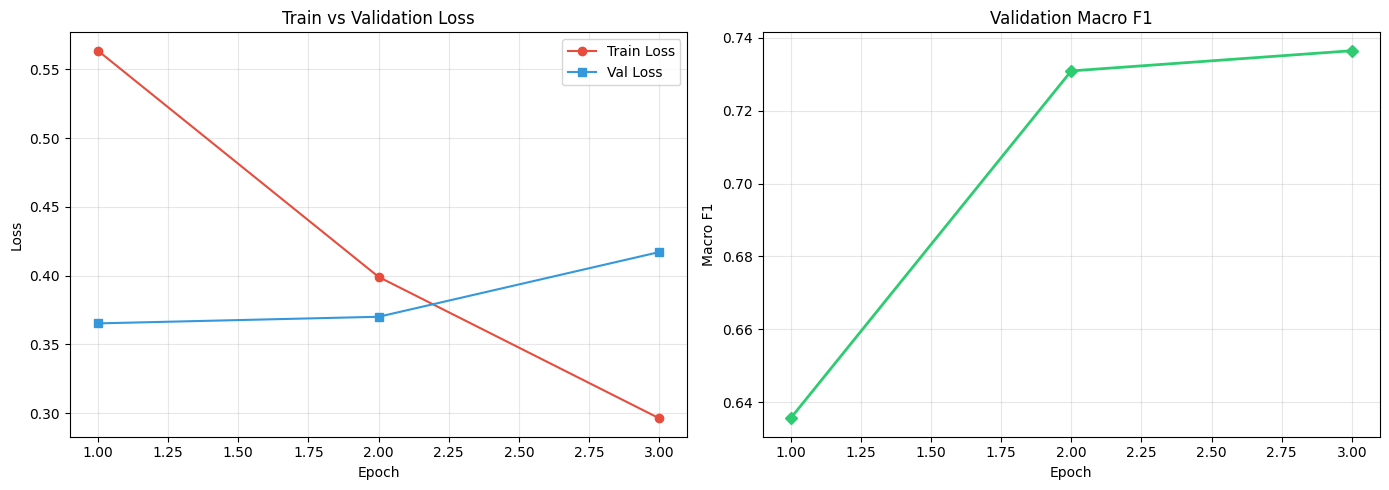

In [24]:
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history["train_loss"], "o-", label="Train Loss", color="#e74c3c")
ax1.plot(epochs_range, history["val_loss"],   "s-", label="Val Loss",   color="#3498db")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Train vs Validation Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history["val_macro_f1"], "D-", color="#2ecc71", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro F1")
ax2.set_title("Validation Macro F1")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "training_curves.png"), dpi=100, bbox_inches="tight")
plt.show()

In [25]:
best_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)
best_model = best_model.to(DEVICE)
print(f"Best model loaded from {SAVE_DIR}")

test_loss, test_logits, test_labels_arr = evaluate(best_model, test_loader, criterion, DEVICE)
test_probs = torch.sigmoid(torch.tensor(test_logits)).numpy()
test_preds = (test_probs >= 0.5).astype(int)

print("\n" + "="*70)
print("  TEST SET — OVERALL RESULTS")
print("="*70)
print(classification_report(test_labels_arr, test_preds, target_names=LABELS, zero_division=0))

overall_macro_f1    = f1_score(test_labels_arr, test_preds, average="macro",    zero_division=0)
overall_weighted_f1 = f1_score(test_labels_arr, test_preds, average="weighted", zero_division=0)
overall_accuracy    = accuracy_score(test_labels_arr.flatten(), test_preds.flatten())
print(f"Overall Accuracy:    {overall_accuracy:.4f}")
print(f"Overall Macro F1:    {overall_macro_f1:.4f}")
print(f"Overall Weighted F1: {overall_weighted_f1:.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Best model loaded from /kaggle/working/hatespeech-best

  TEST SET — OVERALL RESULTS
                 precision    recall  f1-score   support

          clean       0.99      0.96      0.97     14489
      profanity       0.64      0.93      0.76       946
    hate_speech       0.76      0.90      0.83      1967
         threat       0.44      0.81      0.57        86
identity_attack       0.37      0.81      0.51       148

      micro avg       0.92      0.95      0.93     17636
      macro avg       0.64      0.88      0.73     17636
   weighted avg       0.93      0.95      0.94     17636
    samples avg       0.94      0.95      0.94     17636

Overall Accuracy:    0.9714
Overall Macro F1:    0.7281
Overall Weighted F1: 0.9410


In [26]:
print("="*70)
print("  TEST SET — BY LANGUAGE")
print("="*70)

lang_results = {}
for lang, lang_name in [("en", "English"), ("ne", "Nepali")]:
    mask = (test_df["language"] == lang).values
    if mask.sum() == 0:
        print(f"  {lang_name}: No samples in test set.")
        continue

    l_true  = test_labels_arr[mask]
    l_pred  = test_preds[mask]
    l_macro = f1_score(l_true, l_pred, average="macro", zero_division=0)
    l_per   = f1_score(l_true, l_pred, average=None,    zero_division=0)
    l_acc   = accuracy_score(l_true.flatten(), l_pred.flatten())

    lang_results[lang_name] = {"macro_f1": l_macro, "accuracy": l_acc,
                                "per_class": dict(zip(LABELS, l_per.tolist()))}

    print(f"\n  {lang_name} ({mask.sum()} samples):")
    print(f"    Accuracy:  {l_acc:.4f}")
    print(f"    Macro F1:  {l_macro:.4f}")
    for lbl, f1 in zip(LABELS, l_per):
        print(f"      {lbl:20s}: F1={f1:.4f}")

print("\n" + "="*50)
print(f"{'Language':<12} {'Accuracy':<12} {'Macro F1':<12}")
print("-"*36)
for lang_name, res in lang_results.items():
    print(f"{lang_name:<12} {res['accuracy']:.4f}       {res['macro_f1']:.4f}")

  TEST SET — BY LANGUAGE

  English (15927 samples):
    Accuracy:  0.9746
    Macro F1:  0.7154
      clean               : F1=0.9777
      profanity           : F1=0.7731
      hate_speech         : F1=0.8136
      threat              : F1=0.5035
      identity_attack     : F1=0.5092

  Nepali (572 samples):
    Accuracy:  0.8829
    Macro F1:  0.6778
      clean               : F1=0.6957
      profanity           : F1=0.6479
      hate_speech         : F1=0.8923
      threat              : F1=0.6667
      identity_attack     : F1=0.4865

Language     Accuracy     Macro F1    
------------------------------------
English      0.9746       0.7154
Nepali       0.8829       0.6778


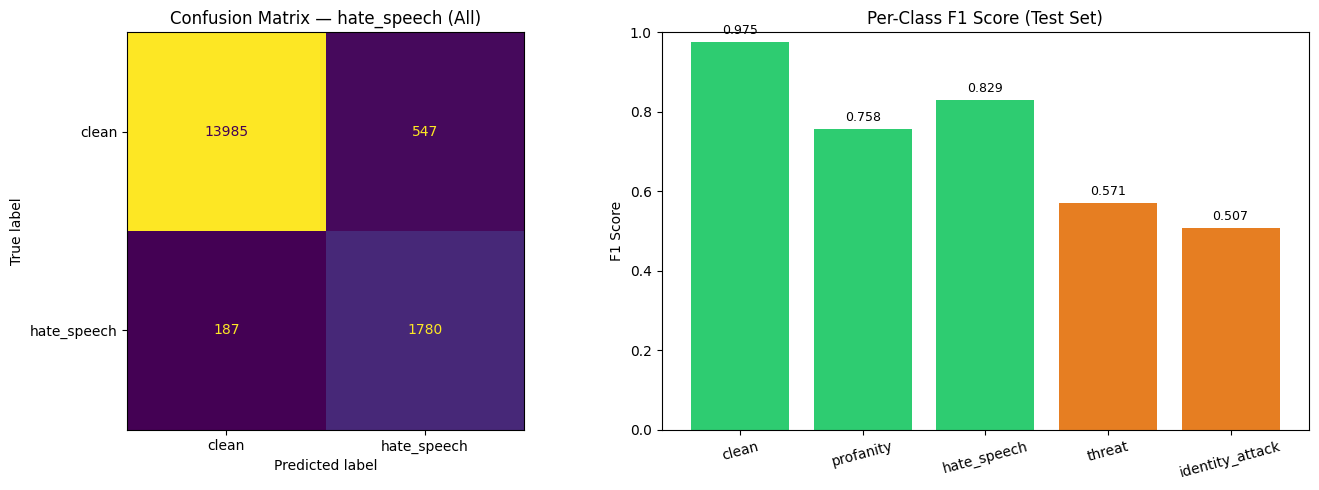

In [27]:
hs_idx  = LABELS.index("hate_speech")
hs_true = test_labels_arr[:, hs_idx].astype(int)
hs_pred = test_preds[:, hs_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(hs_true, hs_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["clean", "hate_speech"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — hate_speech (All)")

final_per_cls = f1_score(test_labels_arr, test_preds, average=None, zero_division=0)
colors = ["#2ecc71" if f > 0.7 else "#e67e22" if f > 0.4 else "#e74c3c" for f in final_per_cls]
axes[1].bar(LABELS, final_per_cls, color=colors)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Class F1 Score (Test Set)")
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(final_per_cls):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "test_evaluation.png"), dpi=100, bbox_inches="tight")
plt.show()

## Baseline Comparison

TF-IDF + Logistic Regression trained on English-only binary hate speech classification. This demonstrates the value of the multilingual transformer approach.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

train_en = train_df[train_df["language"] == "en"][["text", "hate_speech"]].dropna()
test_en  = test_df[test_df["language"]   == "en"][["text", "hate_speech"]].dropna()

print(f"Baseline data: {len(train_en):,} train / {len(test_en):,} test (English only)")

tfidf  = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)
X_tr   = tfidf.fit_transform(train_en["text"])
X_te   = tfidf.transform(test_en["text"])
y_tr   = train_en["hate_speech"].values
y_te   = test_en["hate_speech"].values

lr = LogisticRegression(max_iter=500, C=1.0, class_weight="balanced", random_state=SEED)
lr.fit(X_tr, y_tr)
lr_preds = lr.predict(X_te)

baseline_f1  = f1_score(y_te, lr_preds, average="macro", zero_division=0)
baseline_acc = accuracy_score(y_te, lr_preds)
print(f"\nTF-IDF + LR — Macro F1: {baseline_f1:.4f} | Accuracy: {baseline_acc:.4f}")
print(classification_report(y_te, lr_preds, target_names=["clean","hate_speech"], zero_division=0))

en_mask     = (test_df["language"] == "en").values
xlmr_en_f1  = f1_score(test_labels_arr[en_mask, hs_idx].astype(int),
                        test_preds[en_mask, hs_idx], average="macro", zero_division=0)

print("\n" + "="*60)
print(f"{'Model':<35} {'Hate F1':>8} {'Multilingual':>14}")
print("-"*60)
print(f"{'TF-IDF + Logistic Regression':<35} {baseline_f1:>8.4f} {'No':>14}")
print(f"{'XLM-RoBERTa (EN+NE)':<35} {xlmr_en_f1:>8.4f} {'Yes':>14}")
print("-"*60)

Baseline data: 127,653 train / 15,927 test (English only)

TF-IDF + LR — Macro F1: 0.8538 | Accuracy: 0.9413
              precision    recall  f1-score   support

       clean       0.98      0.95      0.97     14376
 hate_speech       0.65      0.86      0.74      1551

    accuracy                           0.94     15927
   macro avg       0.82      0.91      0.85     15927
weighted avg       0.95      0.94      0.94     15927


Model                                Hate F1   Multilingual
------------------------------------------------------------
TF-IDF + Logistic Regression          0.8538             No
XLM-RoBERTa (EN+NE)                   0.8955            Yes
------------------------------------------------------------


In [29]:
FINAL_DIR = os.path.join(WORK_DIR, "guardmeet-xlmr-final")
os.makedirs(FINAL_DIR, exist_ok=True)
best_model.save_pretrained(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)

label_map = {i: lbl for i, lbl in enumerate(LABELS)}
with open(os.path.join(FINAL_DIR, "label_map.json"), "w") as f:
    json.dump(label_map, f, indent=2)

metrics_out = {
    "epochs": EPOCHS,
    "best_val_macro_f1": best_val_f1,
    "test_macro_f1_overall": overall_macro_f1,
    "test_weighted_f1": overall_weighted_f1,
    "language_results": lang_results,
    "baseline_tfidf_macro_f1": baseline_f1,
    "history": history
}
with open(os.path.join(WORK_DIR, "training_metrics.json"), "w") as f:
    json.dump(metrics_out, f, indent=2)

print(f"Model saved to {FINAL_DIR}")
print(f"Metrics saved to training_metrics.json")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /kaggle/working/guardmeet-xlmr-final
Metrics saved to training_metrics.json


In [35]:
def predict(text, model, tokenizer, device=DEVICE, threshold=0.5):
    model.eval()
    enc = tokenizer(
        text, max_length=128, padding="max_length",
        truncation=True, return_tensors="pt"
    )
    with torch.no_grad():
        logits = model(
            input_ids=enc["input_ids"].to(device),
            attention_mask=enc["attention_mask"].to(device)
        ).logits
    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    return {
        lbl: {"prob": float(f"{p:.4f}"), "flagged": bool(p >= threshold)}
        for lbl, p in zip(LABELS, probs)
    }


demo_sentences = [
    ("English — hate",      "I hate people like you, get out of here"),
    ("English — threat",    "I will hurt you if you say that again"),
    ("English — clean",     "Great meeting everyone, see you next week!"),
    ("Nepali — hate",       "तिमि हरु यहाँ बाट जाउ, मलाई घृणा लाग्छ"),
    ("Nepali — threat",     "म हान्छु गोली अब आयेर सबै चोरहरुलाई"),
    ("Nepali — clean",      "यस्ता नेता भय पो हून्छ देस मा बिकास।"),
    ("Code-switch — mixed", "yo kasto chora ho, I will report you to the admin"),
]

print("="*70)
print("  SAMPLE INFERENCE")
print("="*70)

for label, text in demo_sentences:
    result  = predict(text, best_model, tokenizer)
    flagged = [k for k, v in result.items() if v["flagged"] and k != "clean"]
    top_prob = max(result.items(), key=lambda x: x[1]["prob"])
    print(f"\n[{label}]")
    print(f"  Text: {text[:60]}")
    print(f"  Flagged: {flagged if flagged else 'none (clean)'}")
    print(f"  Top class: {top_prob[0]} ({top_prob[1]['prob']:.4f})")
    for lbl, v in result.items():
        bar = '|' * int(v['prob'] * 20)
        flag = " <- FLAGGED" if v["flagged"] and lbl != "clean" else ""
        print(f"    {lbl:20s} {v['prob']:.4f} {bar}{flag}")

  SAMPLE INFERENCE

[English — hate]
  Text: I hate people like you, get out of here
  Flagged: ['hate_speech']
  Top class: hate_speech (0.9960)
    clean                0.0072 
    profanity            0.0853 |
    hate_speech          0.9960 ||||||||||||||||||| <- FLAGGED
    threat               0.0534 |
    identity_attack      0.2874 |||||

[English — threat]
  Text: I will hurt you if you say that again
  Flagged: ['hate_speech', 'threat']
  Top class: hate_speech (0.9592)
    clean                0.0657 |
    profanity            0.0301 
    hate_speech          0.9592 ||||||||||||||||||| <- FLAGGED
    threat               0.7570 ||||||||||||||| <- FLAGGED
    identity_attack      0.0044 

[English — clean]
  Text: Great meeting everyone, see you next week!
  Flagged: none (clean)
  Top class: clean (0.9975)
    clean                0.9975 |||||||||||||||||||
    profanity            0.0020 
    hate_speech          0.0017 
    threat               0.0009 
    identity_attack 